# Ejercicios prácticos - Módulo 6

In [ ]:
pip install bambi preliz nutpie

In [2]:
import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
import preliz as pz
from sklearn.datasets import load_iris

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

### 1. Generar datos sintéticos a partir de una mezcla de 3 gaussianas (por ejemplo usando PreliZ). Ajustar un modelo de mezcla gaussiana finita con 2, 3 o 4 componentes.

Empiezo por generar los datos tal y como indica el enunciado. En este caso decidí utilizar Numpy ya que no logré encontrar una función en PreliZ que me permitiera mezclar 3 gaussianas, lo más cercano que encontré fue el método  [`preliz.unidimensional.combine()`](https://preliz.readthedocs.io/en/latest/unidimensional.html#preliz.unidimensional.combine) pero en su especificación justamente aclara que **la distribución resultante no es una distribución de mezcla**. 

Sin más genero los datos:

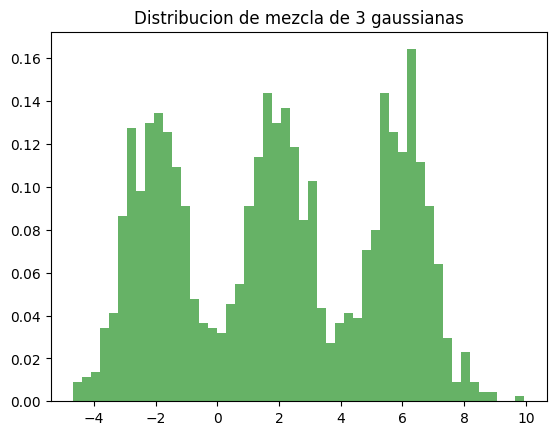

In [8]:
# Defino los parámetros
mu1, sigma1 = -2, 1
mu2, sigma2 = 2, 1
mu3, sigma3 = 6, 1
n_muestras = 500

# Genero los datos sintéticos
data_3_mix = np.concatenate([
    np.random.normal(mu1, sigma1, size=n_muestras),
    np.random.normal(mu2, sigma2, size=n_muestras),
    np.random.normal(mu3, sigma3, size=n_muestras)
])

# Gráfico
plt.hist(data_3_mix, bins=50, density=True, alpha=0.6, color='g')
plt.title('Distribucion de mezcla de 3 gaussianas')
plt.show()

Aquí nada fuera de lo común, podemos ver que `data_3_mix` contiene una combinación de muestras de 3 distribuciones gaussianas con medias diferentes y bastante separadas, la ídea era armar bien el ejemplo.

Ahora construyo modelos con diferentes cantidades de componentes, para esto tomé código "prestado" de la guía:

In [40]:
Ks = [2, 3, 4]

models = []
idatas = []
for k in Ks:
    with pm.Model() as model:
        w = pm.Dirichlet('w', a=np.ones(k))
        μ = pm.Normal('μ',
                      mu=np.quantile(data_3_mix, np.linspace(0.1, 0.9, k)),
                      sigma=data_3_mix.var() / k,
                      shape=k,
                      transform=pm.distributions.transforms.ordered,
                     )
        σ = pm.HalfNormal('σ', sigma=5)
        x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=data_3_mix)
        idata = pm.sample(random_seed=123,
                          idata_kwargs={"log_likelihood":True},
                          progress_bar=False
                         )
        idatas.append(idata)
        models.append(model)

Output()

Output()

Output()

ERROR:pymc.stats.convergence:There were 9 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Podemos ver que el último proceso de muestreo mostró divergencias, esto correspondería al **modelo de 4 componentes**.

Tomando de vuelta código prestado de la guía genero los gráficos para comparar los resultados de los 3 modelos:

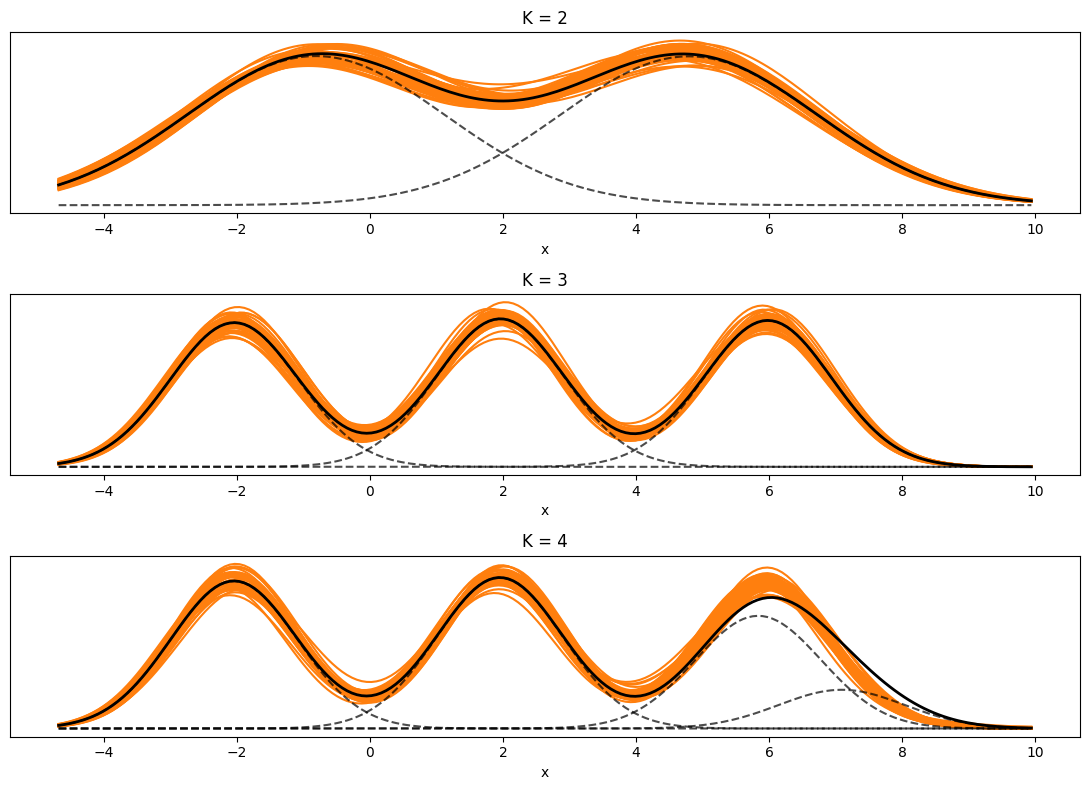

In [41]:
_, ax = plt.subplots(3, 1, figsize=(11, 8))

ax = np.ravel(ax)
x = np.linspace(data_3_mix.min(), data_3_mix.max(), 200)
for idx, idata_x in enumerate(idatas):
    posterior_x = idata_x.posterior.stack(samples=("chain", "draw"))
    x_ = np.array([x] * Ks[idx]).T

    for i_ in np.random.randint(0, posterior_x.samples.size, size=50):
        dist = pz.Normal(posterior_x['μ'][:,i_], posterior_x['σ'][i_])
        ax[idx].plot(x, np.sum(dist.pdf(x_) *  posterior_x['w'][:,i_].values, 1), 'C1')

    p_y = posterior_x['w'].mean("samples")
    dist = pz.Normal(posterior_x['μ'].mean("samples"), posterior_x['σ'].mean())
    ax[idx].plot(x, np.sum(dist.pdf(x_) * p_y.values, 1), 'k', lw=2)
    ax[idx].plot(x, dist.pdf(x_) * p_y.values, 'k--', alpha=0.7)

    ax[idx].set_title('K = {}'.format(Ks[idx]))
    ax[idx].set_yticks([])
    ax[idx].set_xlabel('x')

plt.tight_layout()
plt.show()

A mi parecer **el modelo con 3 componentes es el más razonable**. En el caso de la versión con 2 componentes parece subajustar los datos y en el caso de 4 componentes parece querer captar más patrones de los que hay (observar como se sale en las colas de la distribución). **Creo que este es un claro ejemplo en donde menor complejidad puede resultar en un mejor modelo**.

Otro gráfico que me resultó interesante de mostrar es el de los **p-valores bayesianos**, el valor puntual de esta métrica también nos puede ofrecer una mejor orientación sobre la elección de un modelo:

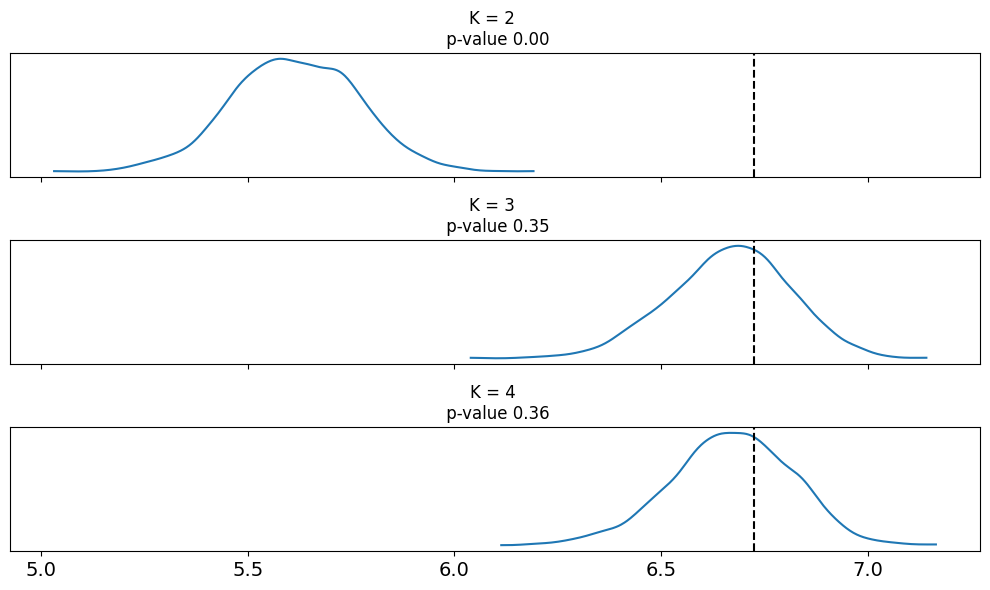

In [43]:
ppc_mm = [pm.sample_posterior_predictive(idatas[i],
                                         models[i],
                                         random_seed=4591,
                                         progressbar=False) for i in range(3)]

fig, ax = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
ax = np.ravel(ax)
def iqr(x, a=0):
    return np.subtract(*np.percentile(x, [75, 25], axis=a))

T_obs = iqr(data_3_mix)
for idx, d_sim in enumerate(ppc_mm):
    d_sim = d_sim.posterior_predictive["x"]
    T_sim = iqr(d_sim, 1)
    p_value = np.mean(T_sim >= T_obs)
    az.plot_kde(T_sim, ax=ax[idx])
    ax[idx].axvline(T_obs, 0, 1, color='k', ls='--')
    ax[idx].set_title(f'K = {Ks[idx]} \n p-value {p_value:.2f}')
    ax[idx].set_yticks([])

plt.tight_layout()
plt.show()

Bueno en este caso nos da **una diferencia de 1 punto** en el p-valor entre los modelos de 3 y 4 componentes. Notar como el modelo de 2 componentes directamente toma un valor de 0, así que confirmamos su incapacidad para ajustar bien los datos.

Si nos basáramos solo en el "numerito" para decidir dijeramos que el de 4 componentes es el ganador, pero **¿vale la pena más complejidad solo por una diferencia de 1 punto?**. Aquí sostengo mi postura de que el modelo de 3 componentes **es mejor por su simpleza** y por mostrar un ajuste similar al modelo de 4 componentes, **aunque hay que tener claro que ninguno de los dos se acerca al valor ideal de 0.5**.

### 2. Usar LOO para comparar los resultados del ejercicio 1.

Vamos ahora tener otra perspectiva con respecto a esta comparación que venimos haciendo y para eso vamos a calcular el ELPD usando LOO.

In [44]:
comp = az.compare(dict(zip([str(K) for K in Ks], idatas)))
comp

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
3,0,-3622.628979,6.174976,0.000000,0.97619,22.631281,0.000000,False,log
4,1,-3622.681582,8.288669,0.052603,0.00000,22.392297,1.121178,False,log
2,2,-3854.571116,3.532448,231.942137,0.02381,12.039527,19.538157,False,log


Aquí la cosa cambia, según esta métrica de comparación el modelo de 3 componentes resulta ser mejor y **toma poco más del 97% del peso si tuviesemos que combinar a los 3 modelos**.

Para terminar esta sección veamos la versión gráfica del ELPD usando LOO:

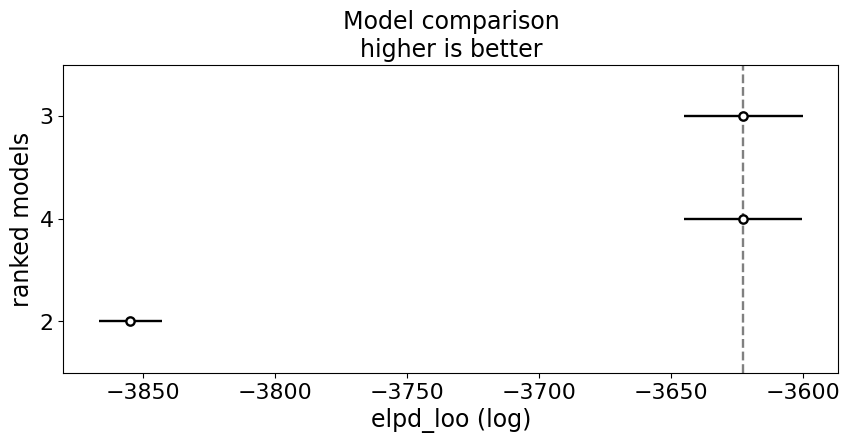

In [45]:
az.plot_compare(comp, figsize=(10, 4), plot_ic_diff=False)
plt.show()

Aquí vemos que la diferencia en la métrica es bastante pequeña, de vuelta, aunque en este caso "gana" el modelo que me gustaba más una diferencia tan pequeña no puede hacernos ir al extremo de tomar uno u otro modelo.

### 3. Leer y ejecutar el siguiente ejemplo sobre modelos de mezcla de la documentación de PyMC. Modelo de [mezcla gaussiana marginalizada](https://www.pymc.io/projects/examples/en/latest/mixture_models/marginalized_gaussian_mixture_model.html)

El autor empieza hablando sobre los **modelos de mezcla gaussianos**, dice que estos son un tipo de modelos flexibles que muestran la heterogeneidad de las subpoblaciones presentes en los datos. Luego procede a armar datos sintéticos bastante parecidos a los del ejercicio 1 y los muestra mediante un gráfico:

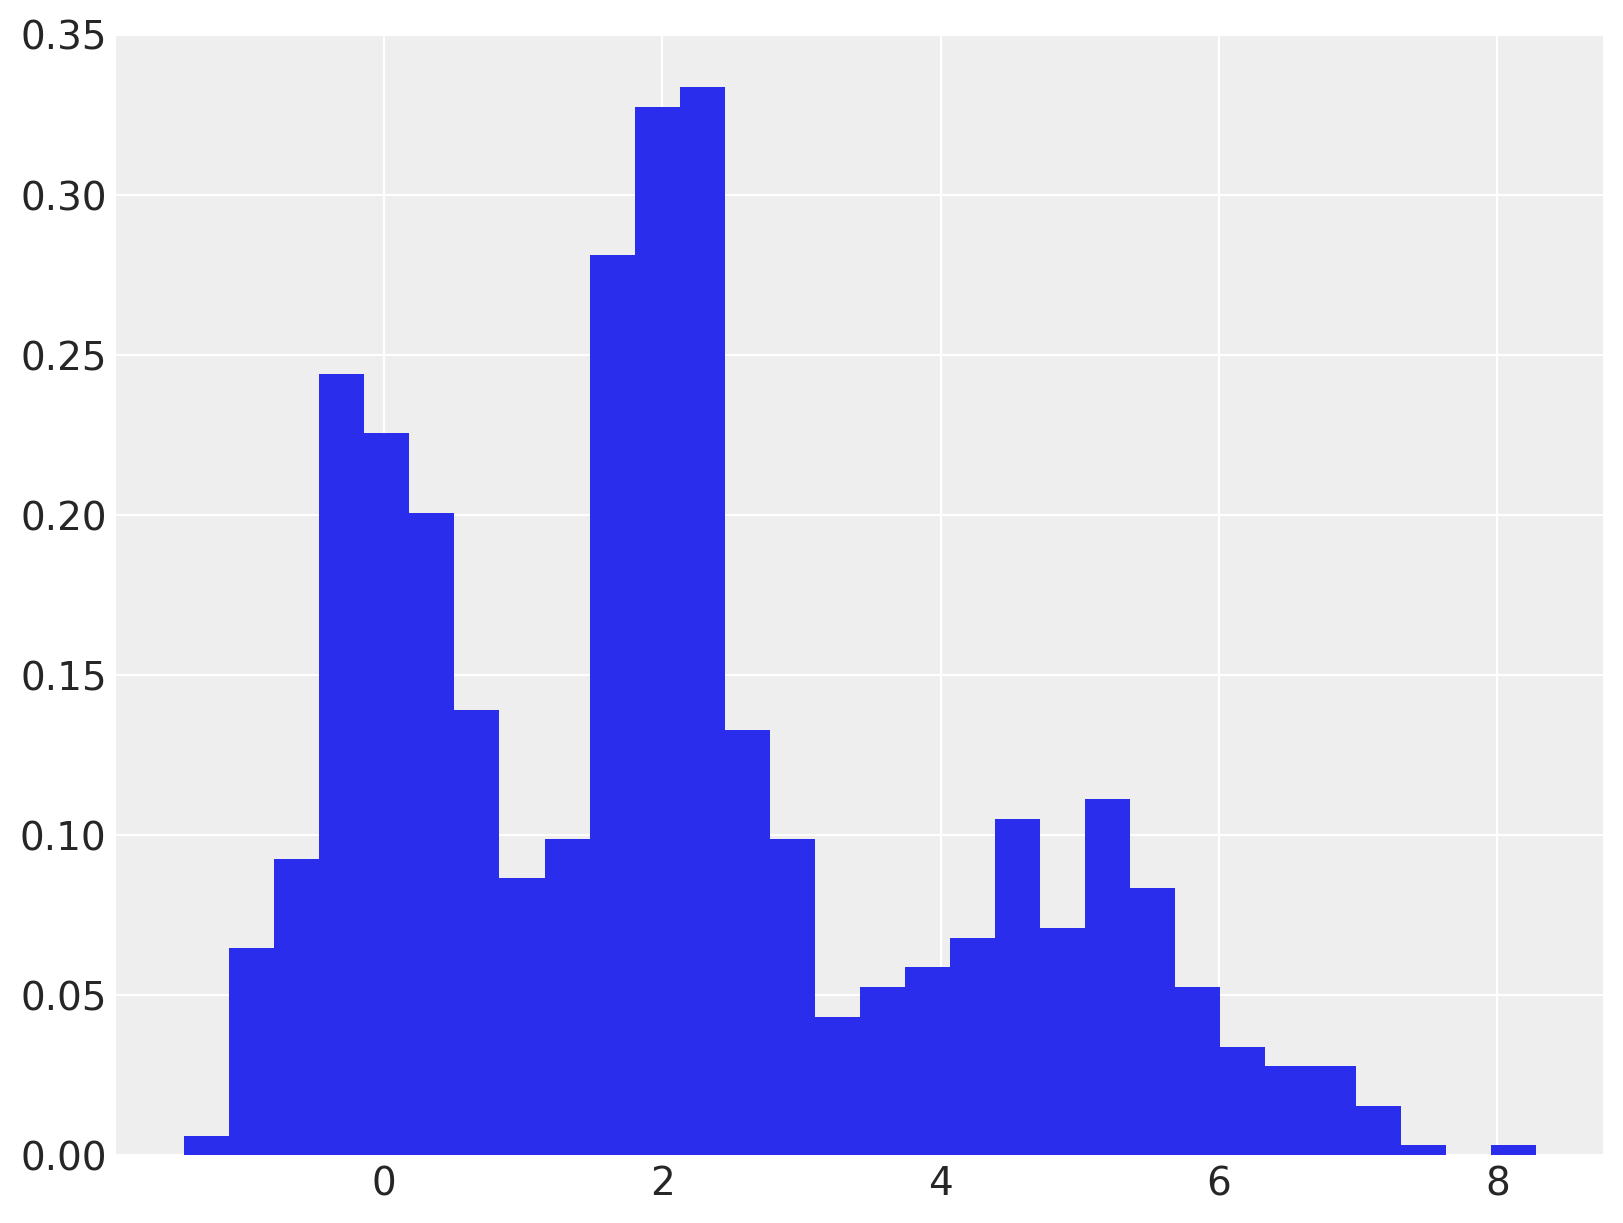

In [71]:
%config InlineBackend.figure_format = 'retina'
RANDOM_SEED = 8927
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-darkgrid")

N = 1000

W = np.array([0.35, 0.4, 0.25])

MU = np.array([0.0, 2.0, 5.0])
SIGMA = np.array([0.5, 0.5, 1.0])

component = rng.choice(MU.size, size=N, p=W)
x = rng.normal(MU[component], SIGMA[component], size=N)

fig, ax = plt.subplots(figsize=(8, 6))

ax.hist(x, bins=30, density=True, lw=0)
plt.show()

El autor luego dice que una parametrización natural de los modelos de mezcla gaussianos está basado en el [modelo de variable latente](https://en.wikipedia.org/wiki/Latent_variable_model).

$$\begin{aligned}
\mu_{1}, \ldots, \mu_{K} &\sim N(0, \sigma^{2}) \\
\tau_{1}, \ldots, \tau_{K} &\sim \text{Gamma}(a, b) \\
\mathbf{w} &\sim \text{Dir}(\mathbf{\alpha}) \\
z \mid \mathbf{w} &\sim \text{Cat}(\mathbf{w}) \\
x \mid z &\sim N(\mu_{z}, \tau_{z}^{-1})
\end{aligned}$$

El autor indica que una implementación de esta parametrización está disponible en PyMC. Luego menciona que una desventaja de esta parametrización es el hecho de que **se tienen que tomar muestras de la variable latente discreta $z$**. Esto puede provocar un retraso en el proceso y por ende una exploración con poco provecho en torno a las colas de la distribución.

Luego el autor menciona la existencia de una versión alternativa y equivalente a esta parametrización, que lo que hace para resolver el problema es marginalizar sobre $z$. Dicha versión marginalizada es de la forma:

$$\begin{aligned}
\mu_{1}, \ldots, \mu_{K} &\sim N(0, \sigma^{2}) \\
\tau_{1}, \ldots, \tau_{K} &\sim \text{Gamma}(a, b) \\
\mathbf{w} &\sim \text{Dir}(\mathbf{\alpha}) \\
f(x \mid \mathbf{w}) &= \sum_{i=1}^{K} w_{i} N(x \mid \mu_{i}, \tau_{i}^{-1})
\end{aligned}$$
$$

Podemos notar que esta versión es similar a la presentada en el módulo, personalmente creo que es porque es la que se utiliza en la práctica y la actualmente implementada por PyMC. Luego el autor aclara que la distribución normal toma la siguiente forma:

$$N(x \mid \mu, \sigma^{2}) = \frac{1}{\sqrt{2\pi\sigma}}\exp\left(-\frac{1}{2\sigma^{2}}(x-\mu)^{2}\right)$$

Según el autor **la ventaja que trae marginalizar sobre $z$ es obtener una mejor exploración de la distribución *a posteriori* durante el proceso de muestreo**. Luego menciona que la marginalización sobre variables discretas es un truco común dentro de la comunidad de Stan ya que Stan no soporta la generación de muestras a partir de distribuciones discretas.

Finalmente llegamos a la parte que nos interesa, y es que PyMC **si soporta** una versión marginalizada del modelo de mezcla gaussiano mediante la clase  `NormalMixture`. Finalmente se muestra un ajuste usando dicho modelo (notar que tuve que hacer unos cambios menores porque el autor utiliza parámetros que hoy en día están deprecados por PyMC):

In [75]:
with pm.Model(coords={"cluster": np.arange(len(W)), "obs_id": np.arange(N)}) as model:
    w = pm.Dirichlet("w", np.ones_like(W))

    mu = pm.Normal(
        "mu",
        np.zeros_like(W),
        1.0,
        dims="cluster",
        transform=pm.distributions.transforms.ordered,
        initval=[1, 2, 3],
    )
    tau = pm.Gamma("tau", 1.0, 1.0, dims="cluster")

    x_obs = pm.NormalMixture("x_obs", w, mu, tau=tau, observed=x, dims="obs_id")

In [78]:
with model:
    trace = pm.sample(5000, n_init=10000, tune=1000, return_inferencedata=True)

    # sample posterior predictive samples
    trace.extend(pm.sample_posterior_predictive(trace, var_names=["x_obs"], progressbar=False))

Output()

Podemos ahora ver en el gráfico de abajo que la distribución *a posteriori* del modelo obtenida captó bastante bien la media y pesos asignados:

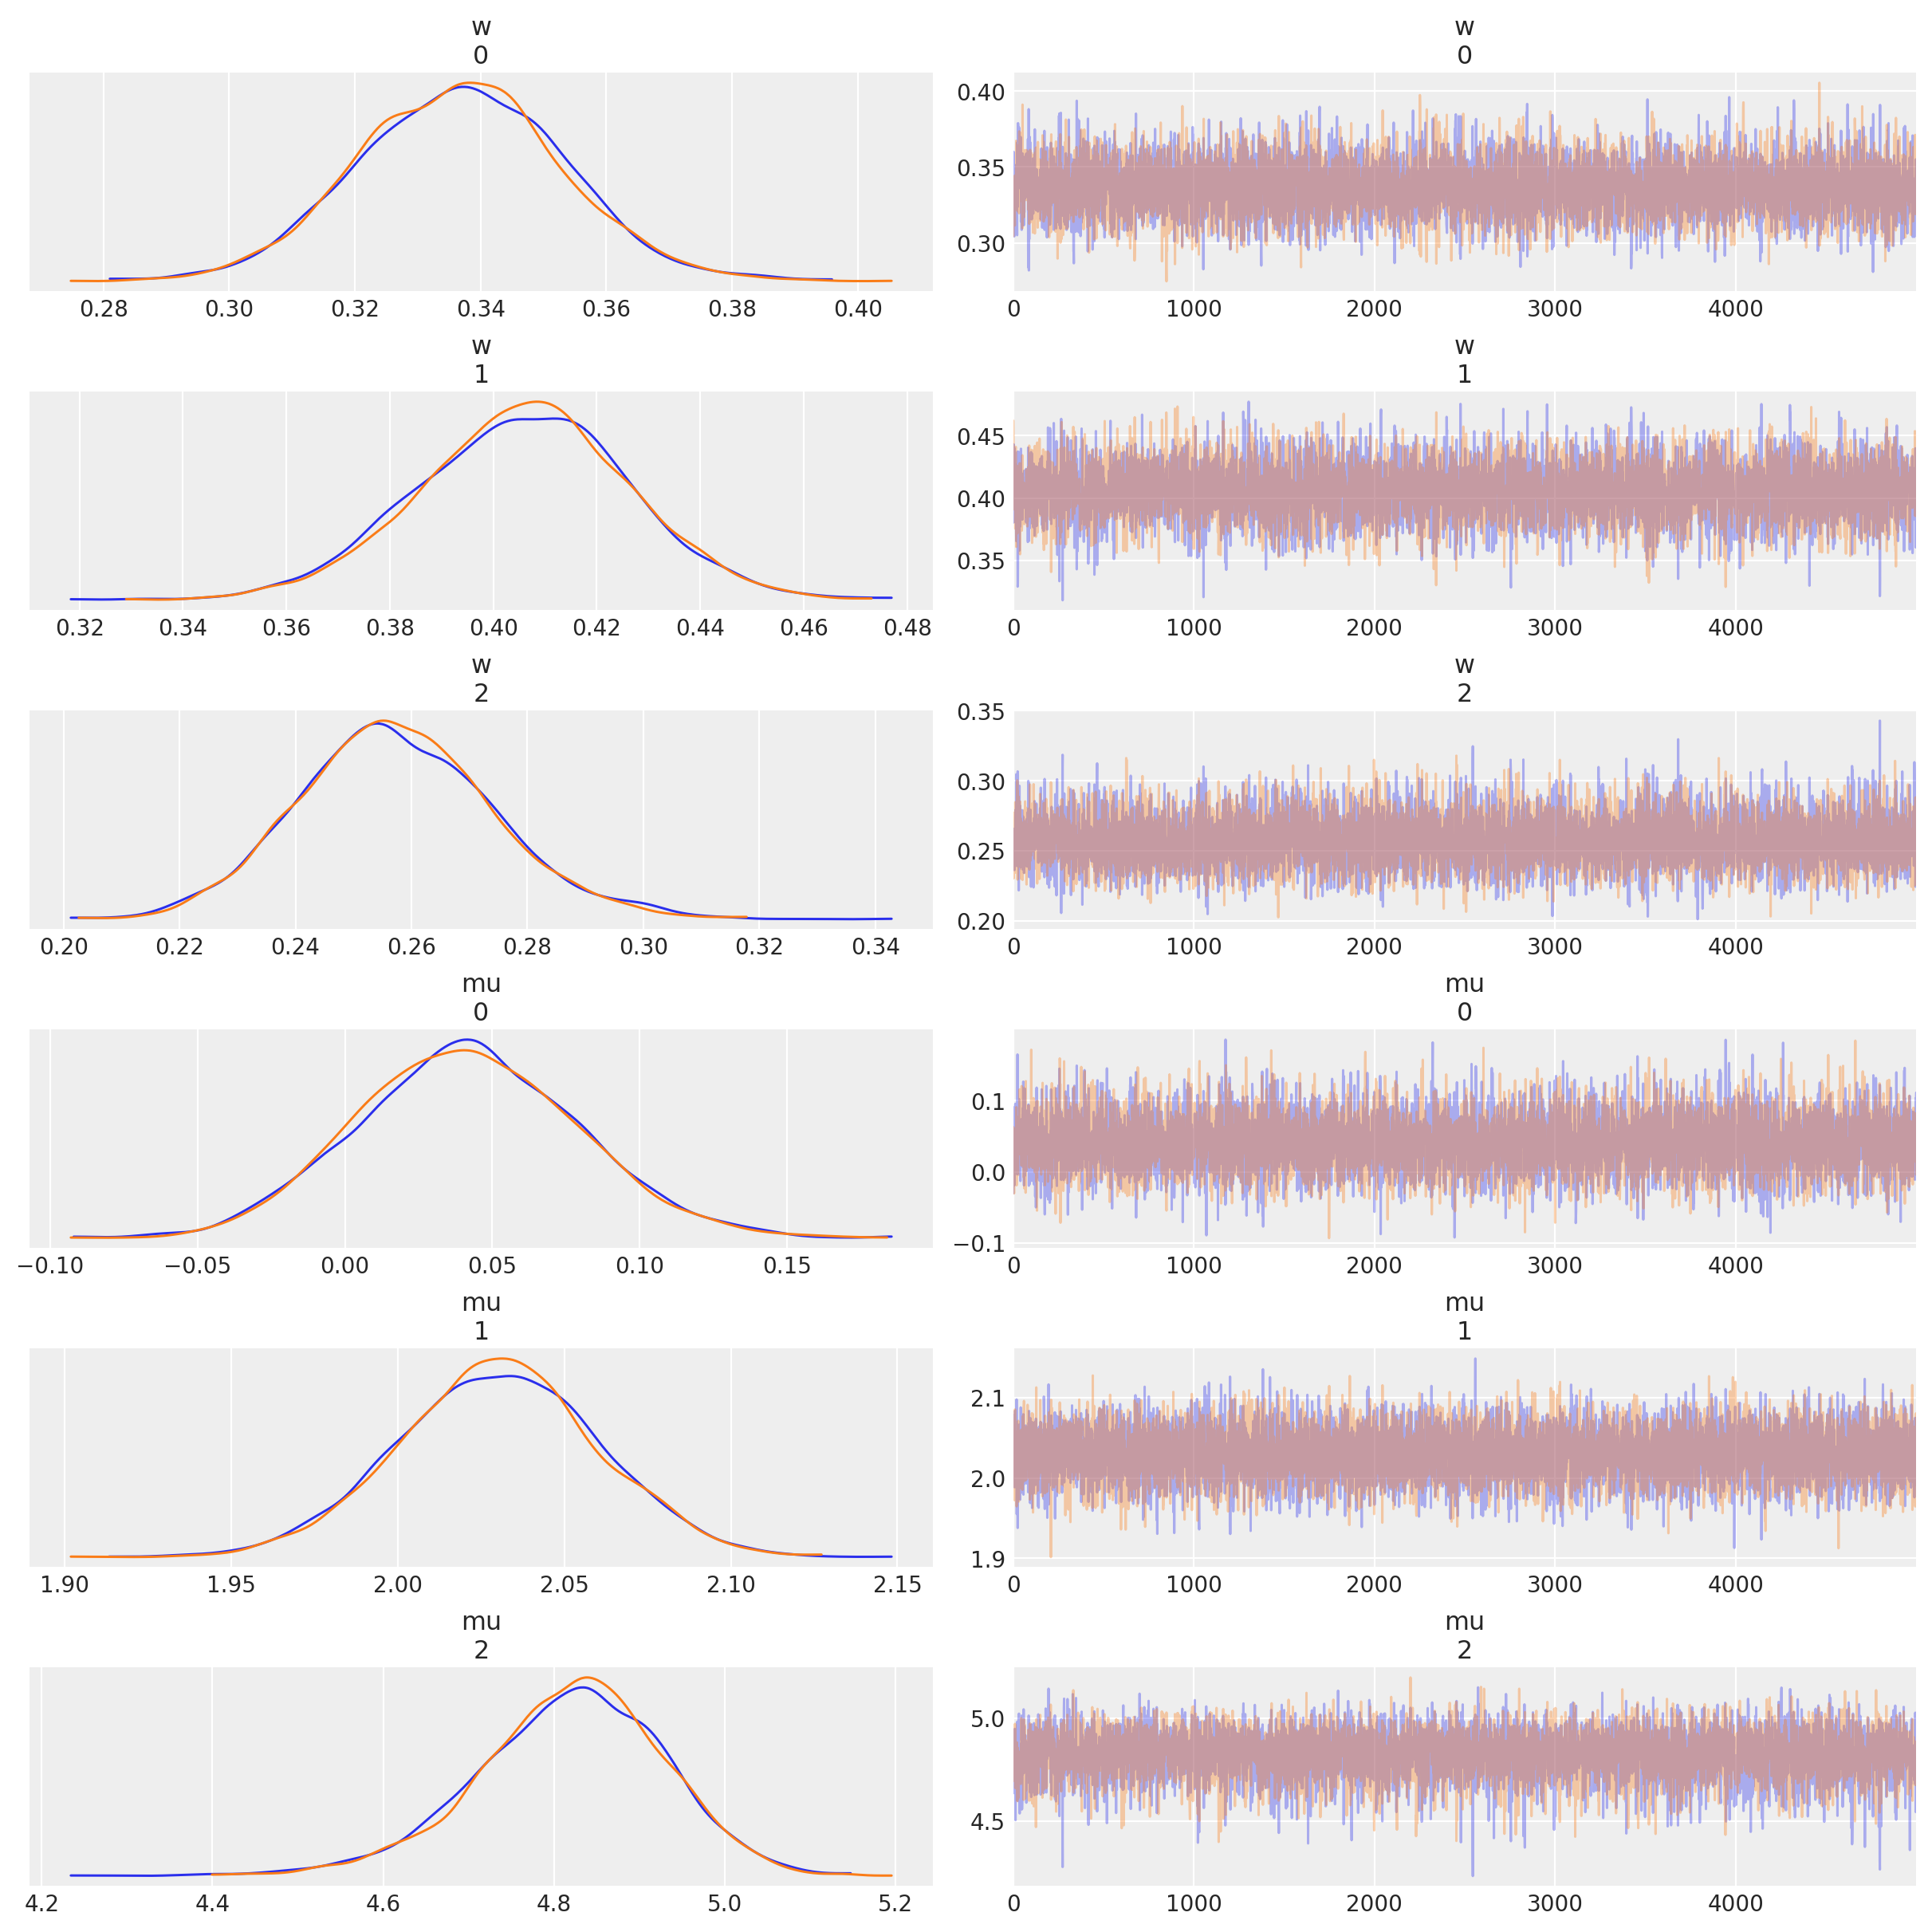

In [84]:
az.plot_trace(trace, var_names=["w", "mu"], compact=False)
plt.show()

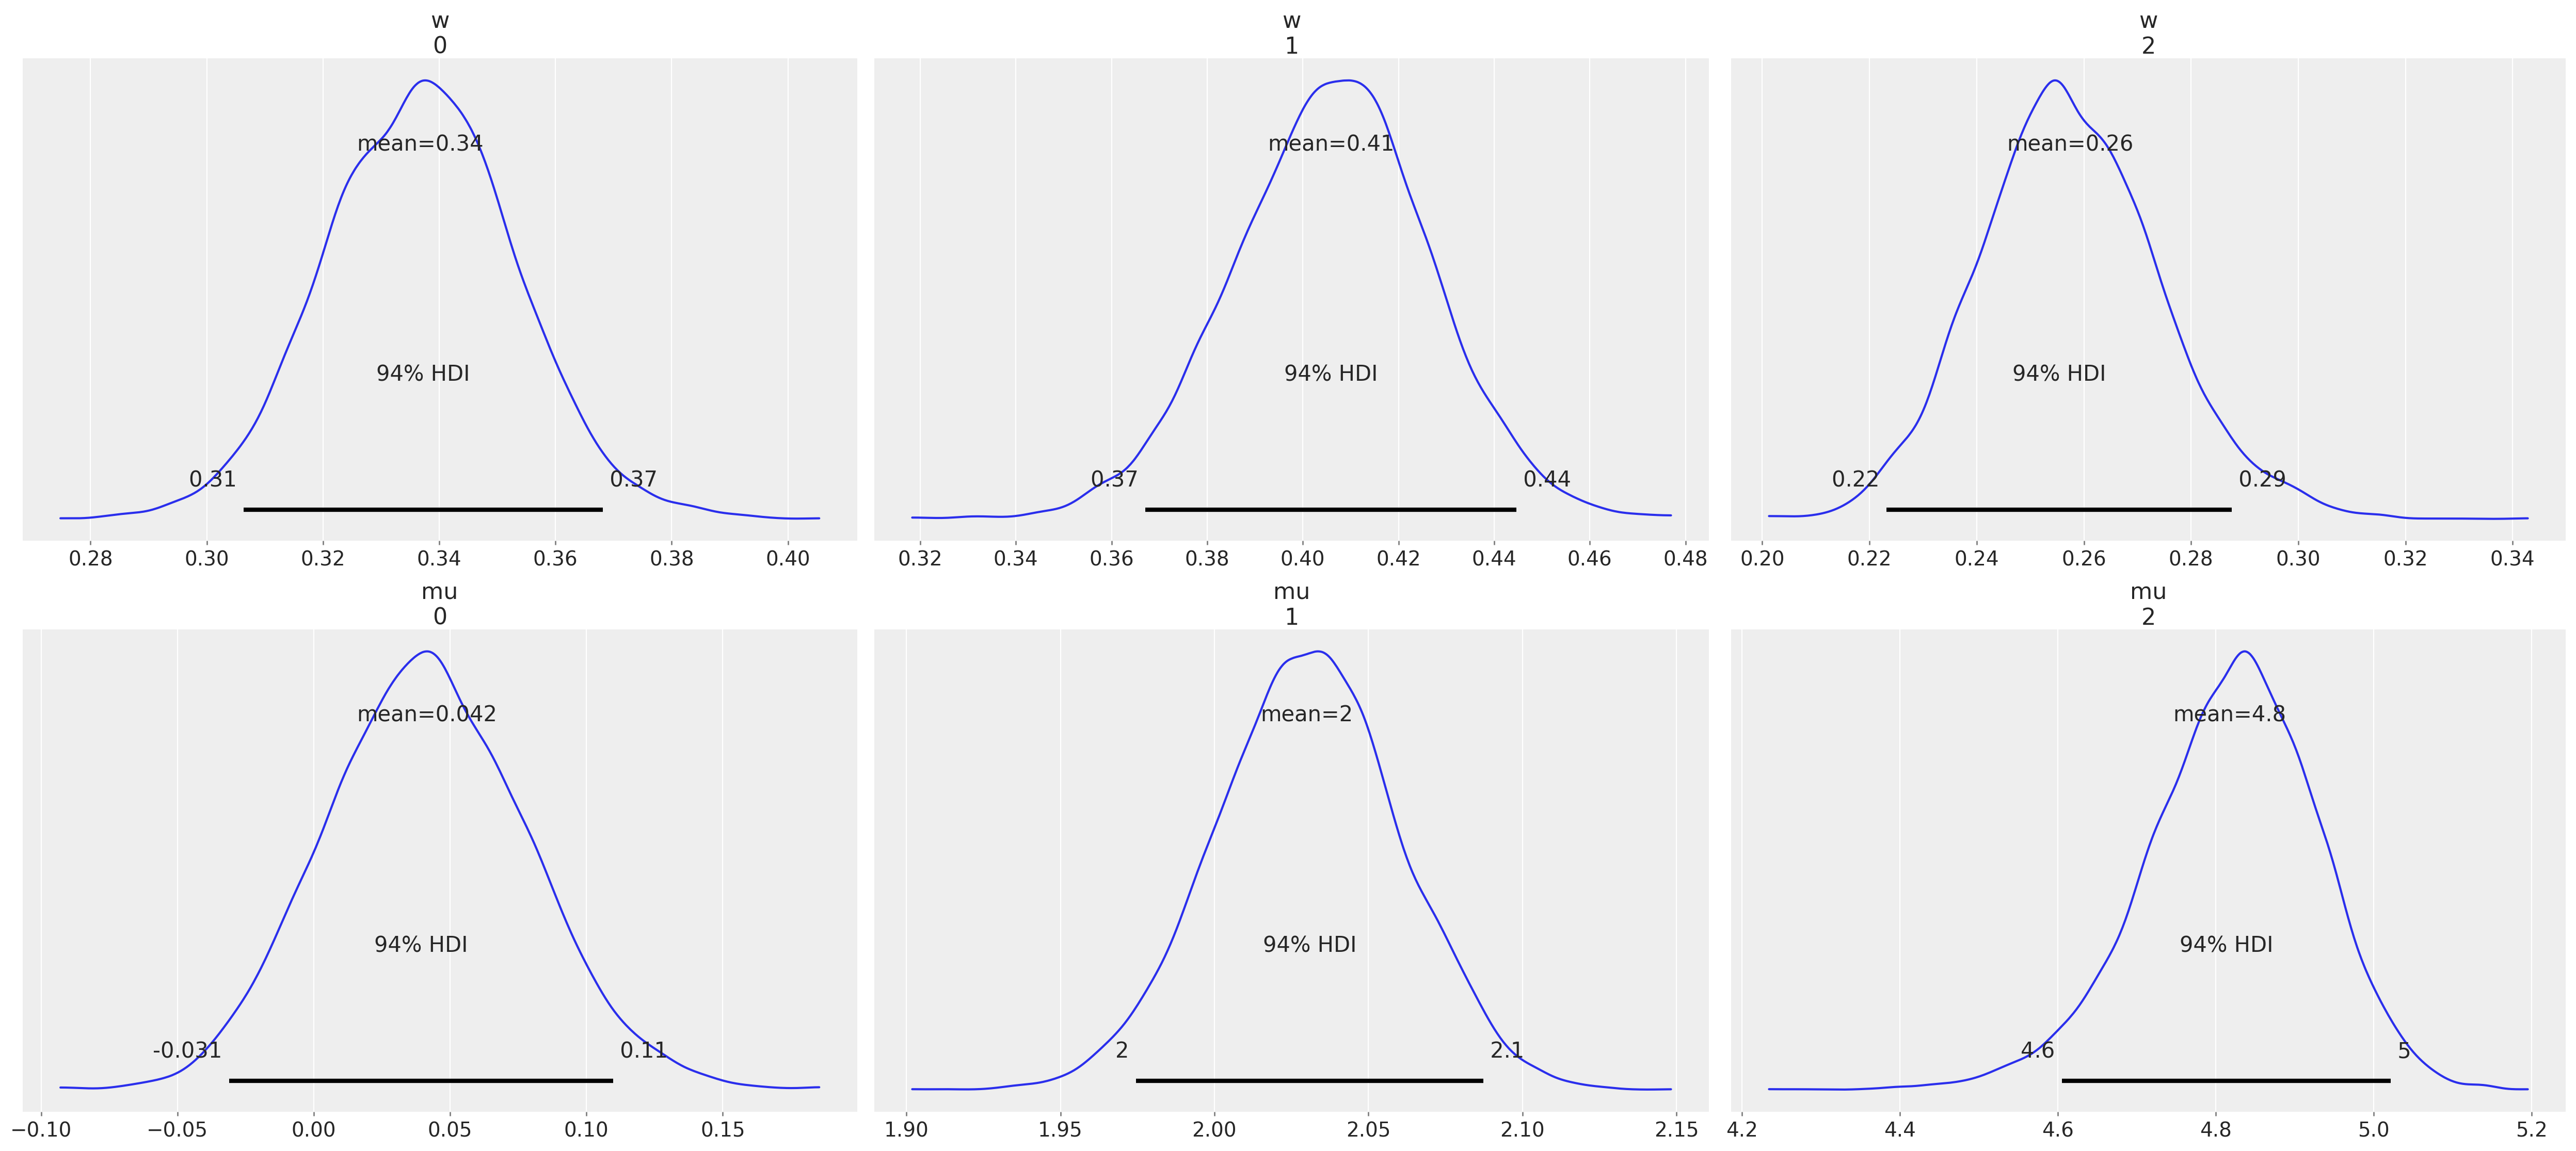

In [86]:
az.plot_posterior(trace, var_names=["w", "mu"])
plt.show()

Observamos del mismo modo que las muestras de la distribución *a posteriori* predictiva también se distribuyen de forma bastante similar a los datos:

<Axes: xlabel='x_obs'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


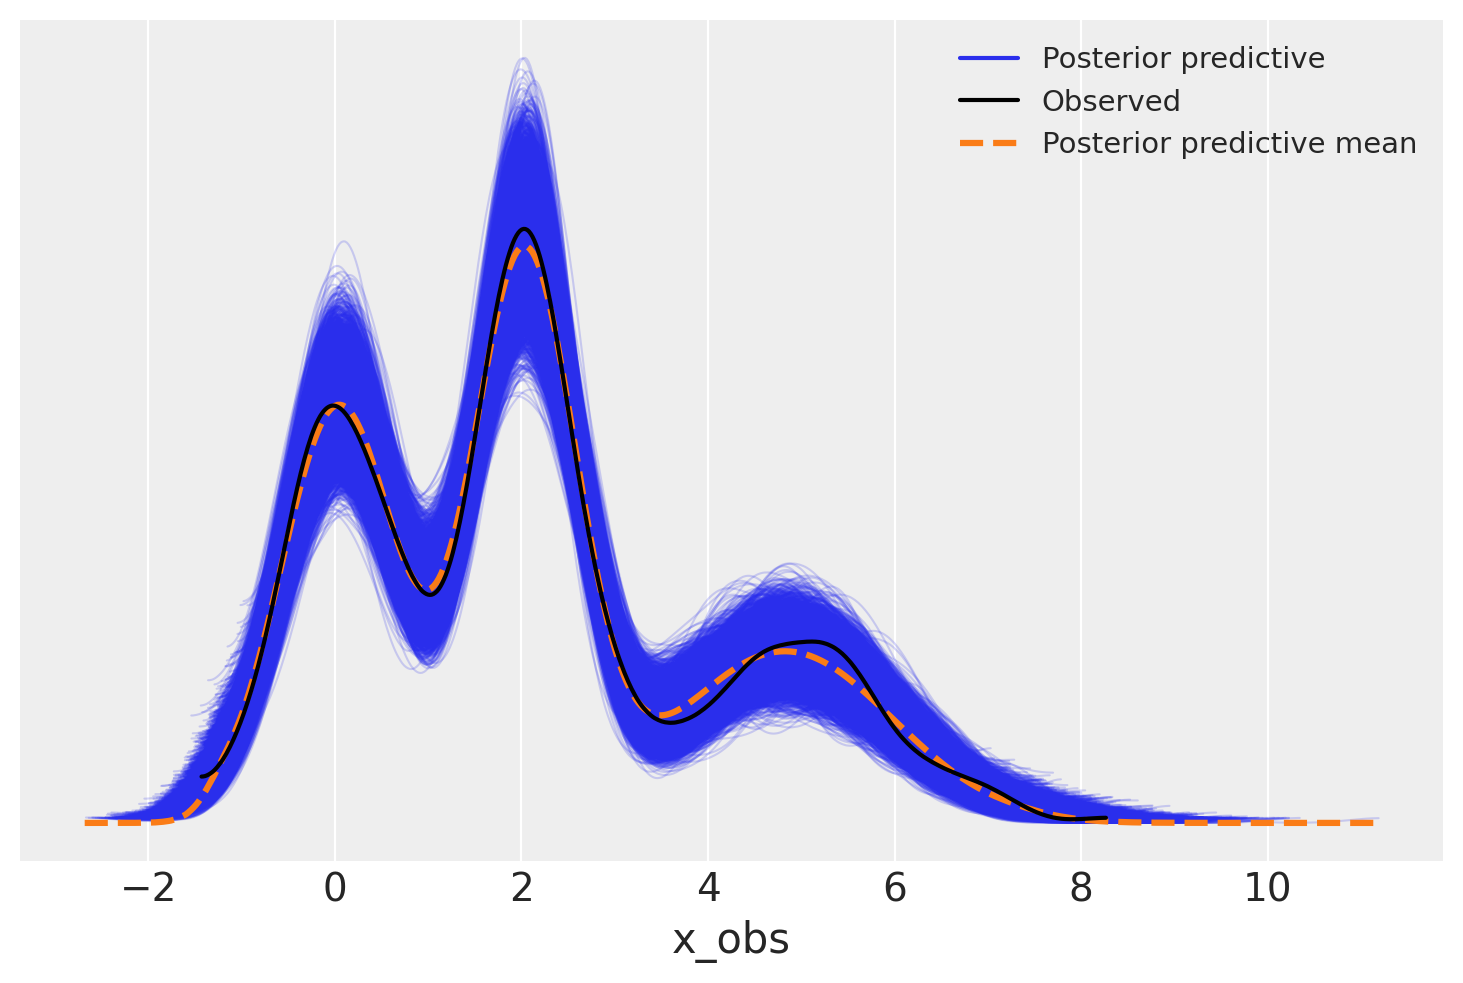

In [87]:
az.plot_ppc(trace)

### 4. Usando los datos de pezca ajuste un modelo NegativeBinomial y un Hurdle-NegativeBinomial. Use rootogramas para comparar estos dos modelos con el modelo de Poisson inflado de ceros.

Antes de empezar el ejercicio quiero aclarar que no pude implementarlo utilizando el modelo Hurdle-NegativeBinomial, este último nunca logró terminar de generar muestras por más de que el proceso parecía exitoso (la barra de progreso mostraba que ya había tomado todas las muestras). **Reemplacé a este modelo por un Hurdle-Poisson implementado en Bambi**.

Empiezo por cargar los datos de pezca utilizados en el módulo:

In [46]:
pesca = pd.read_csv('pesca.csv')
pesca.head()

,nofish,livebait,camper,persons,child,count
0,1,0,0,1,0,0
1,0,1,1,1,0,0
2,0,1,0,1,0,0
3,0,1,1,2,1,0
4,0,1,0,1,0,1


Vuelvo a reconstruir al modelo `ZIP_reg` mostrado en el módulo para poder llevar a cabo la comparación:

In [64]:
with pm.Model() as ZIP_reg:
    ψ = pm.Beta('ψ', 1, 1)
    α = pm.Normal('α', 0, 1)
    β = pm.Normal('β', 0, 1, shape=2)
    θ = pm.math.exp(α + β[0] * pesca['child'] + β[1] * pesca['camper'])
    yl = pm.ZeroInflatedPoisson('count', ψ, θ, observed=pesca['count'])
    idata_ZIP_reg = pm.sample(idata_kwargs={"log_likelihood":True}, random_seed=123)
    idata_ZIP_reg.extend(pm.sample_posterior_predictive(idata_ZIP_reg, progressbar=False))

Output()

Ahora genero los dos modelos que servirán para la comparación: `modelo_negativebinomial` y `modelo_h_poisson`. Ambos corresponden a los modelos NegativeBinomial y un Hurdle-Poisson propuestos al principio. Para hacer más fácil las cosas voy a utilizar la implementación que ofrece Bambi:

In [60]:
# Modelo negativo binomial
modelo_negativebinomial = bmb.Model("count ~ child + C(camper)", family="negativebinomial", data=pesca)
idata_neg_bin = modelo_negativebinomial.fit(idata_kwargs={"log_likelihood":True})
modelo_negativebinomial.predict(idata_neg_bin, kind="pps")

# Modelo hurdle poisson
modelo_h_poisson = bmb.Model("count ~ child + C(camper)", family="hurdle_poisson", data=pesca)
idata_h_pos = modelo_h_poisson.fit(idata_kwargs={"log_likelihood":True})
modelo_h_poisson.predict(idata_h_pos, kind="pps")

Output()

Output()

Con el muestreo listo procedo a generar el gráfico de rotogramas (prestando código de vuelta, ja) y así llevar a cabo la comparación final:

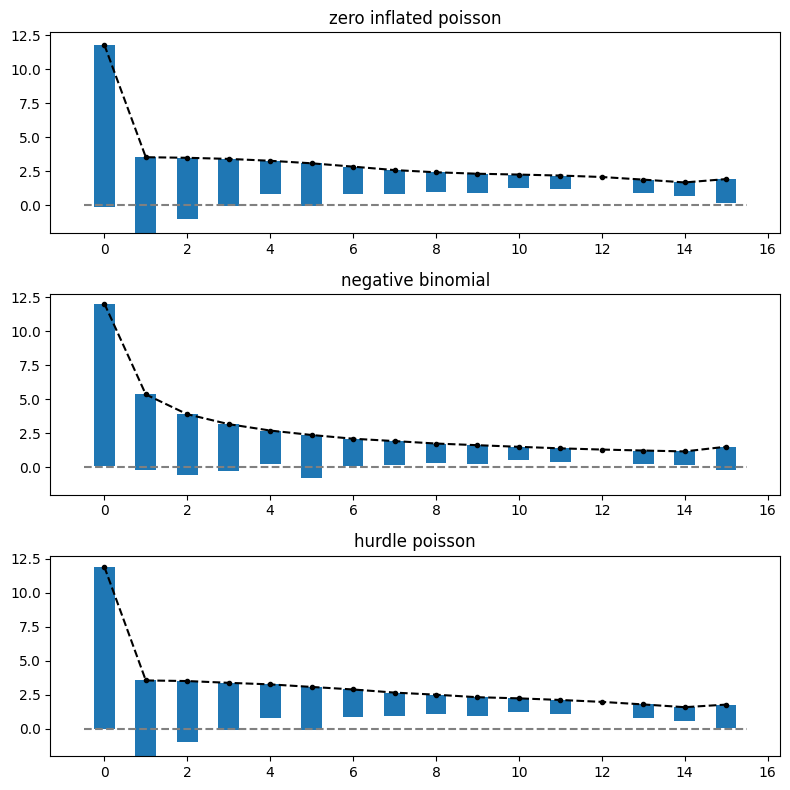

In [68]:
def rotogram(idata, ax):
    max_ = 17
    bins = np.array(range(0, max_))
    dims = idata.posterior_predictive.dims
    n_samples = dims["chain"] * dims["draw"]
    pred =  (np.histogram(idata.posterior_predictive["count"].values.ravel(),  bins=bins)[0] / n_samples)**0.5
    observed = np.histogram(pesca["count"].values, bins=bins)[0]**0.5

    ax.bar(bins[:-1], observed, 0.5, bottom=pred-observed, color="C0")
    ax.plot(bins[:-1], pred,  "k.--")
    ax.hlines(0, -0.5, max_-1.5, linestyle="--", color="0.5")

idatas = [idata_ZIP_reg, idata_neg_bin, idata_h_pos]
modelos = [ZIP_reg, modelo_negativebinomial, modelo_h_poisson]
titulos = ['zero inflated poisson', 'negative binomial', 'hurdle poisson']
fig, axes = plt.subplots(3, 1, sharey=True, figsize=(8, 8))
for ax, idata, model, title in zip(axes.ravel(), idatas, modelos, titulos):
    rotogram(idata, ax)
    ax.set_title(title)

plt.tight_layout()

A partir del gráfico hago un resumen de lo observado para las 3 distribuciones:

* **Zero Inflated Poisson**: El 1 y el 2 están subestimados y los conteos posteriores al 3 están casi todos sobreestimados. Cabe destacar que al ser un modelo inflado en cero este genera una estimación correcta para el mismo.

* **NegativoBinomial**: Este **parece ser el que mejor se comporta** en lineas generales. Hay casos puntuales como el del 5 en donde se subestima y el 12 en donde se sobreestima.

* **Hurdle Poisson**: Este resultó tener varios problemas si miramos valores diferentes al cero. Al 1 y al 2 los subestimó mientras que a valores posteriores al 3 fueron todos sobreestimados, **algo parecido a lo que hizo su contraparte inflada en cero**.

### 5. Repita el ejercicio 1 utilizando un proceso de Dirichlet.

Bueno aprovecho que ya generé los datos y ahora me propongo a definir una versión de el modelo visto en el ejercicio 1, llamado `modelmix_3_DP`. En este caso vuelto a tomar código prestado del módulo pero reemplazando por los datos que generé antes, notar que también usé el mismo valor de truncamiento $K=10$. Mantenerlo puede resultar interesante ya que sabemos que habrían 3 componentes principales en nuestros datos, pero resultar interesante ver que hace para mayor cantidad de componentes.

Sin más defino la estructura del modelo:

In [13]:
K = 10

with pm.Model() as modelmix_3_DP:
    α = pm.Gamma('α', 2, 1)

    w = pm.StickBreakingWeights("w", α, K-1)
    means = pm.Normal('means',
                      mu=np.linspace(data_3_mix.min(), data_3_mix.max(), K),
                      sigma=5, shape=K,
                      transform=pm.distributions.transforms.ordered,
                     )

    sd = pm.HalfNormal('sd', sigma=5, shape=K)
    obs = pm.NormalMixture('obs', w, means, sigma=sd, observed=data_3_mix)
    idata_DP = pm.sample(random_seed=123, target_accept=0.9, nuts_sampler="nutpie")

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,253,0.08,63
,2000,22,0.12,31


Ahora para resaltar lo interesante de haber mantenido ese valor para $K$ voy a generar otro gráfico que tomaré prestado del módulo. Este es el gráfico de la distribución *a posteriori* para los pesos $w_i$:

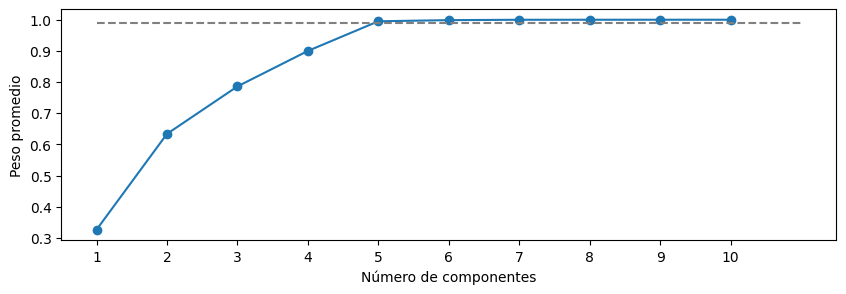

In [57]:
_, ax = plt.subplots(figsize=(10, 3))
plot_w = np.arange(K)
ax.plot(np.cumsum(np.sort(idata_DP.posterior['w'].mean(("chain", "draw")))[::-1]), 'o-')
ax.hlines(0.99, 0, K, ls="--", color="0.5")
ax.set_xticks(plot_w, plot_w+1)
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Peso promedio');

Podemos ver que **los primeros 5 componentes ya representan al 99% del peso total** (línea discontinua gris en la figura anterior) y por lo tanto podemos estar seguros de que el valor elegido $K=10$ fue una elección correcta o a lo mejor un tanto desproporcionada.

Ahora como último acto voy a tomar muestras de la distribución *a posteriori* predictiva:

In [ ]:
with modelmix_3_DP:
  idata_DP.extend(pm.sample_posterior_predictive(idata_DP, progressbar=False))

Genero un gráfico a partir de las muestras:

[]

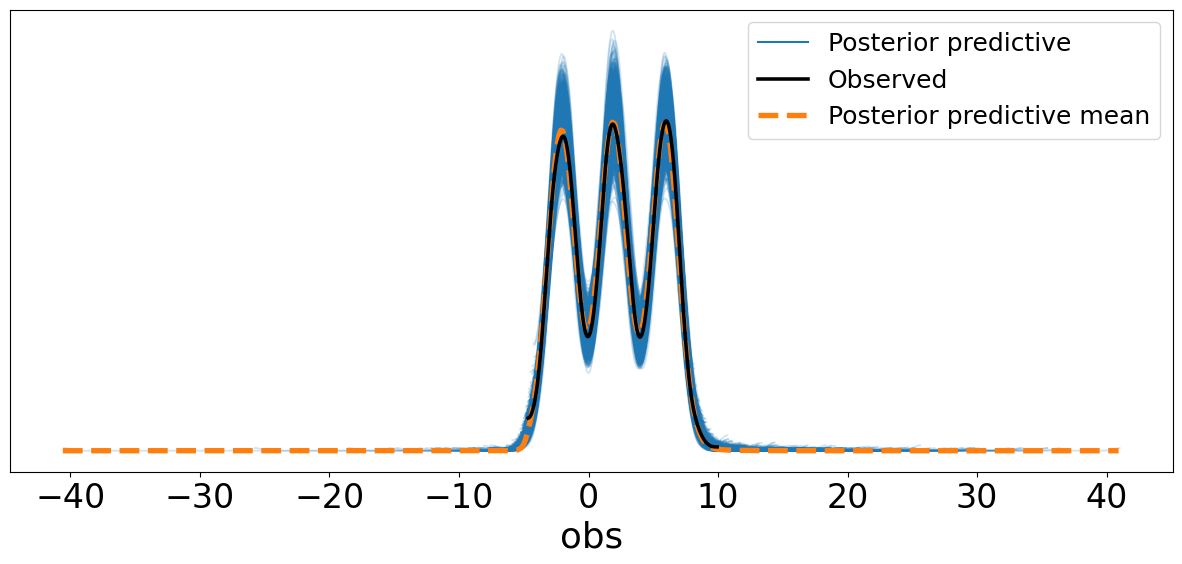

In [58]:
az.plot_ppc(idata_DP, figsize=(15, 6))
plt.plot()

Podemos ver que nuestro modelo `modelmix_3_DP` basado en un proceso de Dirichlet ajustó perfectamente a los datos que se generaron.

### 6. Suponiendo por un momento que no conoce las especies/etiquetas correctas para el conjunto de datos de iris, utilice un modelo de mezcla para agrupar las tres especies de iris, utilizando una característica de su elección (como la longitud del sépalo).

Procedo a cargar el conjunto de datos iris, en este caso voy a usar la versión que tiene [Scikit-learn](https://scikit-learn.org/1.4/auto_examples/datasets/plot_iris_dataset.html).

In [22]:
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


Estuve probando diferentes características de las presentes entre lo datos, mi idea era seleccionar una que separara bien a las especies ya que consideré que eso se traduciría a un buen desempeño del modelo. Por ejemplo la característica propuesta `sepal length (cm)` no separaba bien a las especies, mientras que otra como lo es `petal length (cm)` las separa bastante bien.

Veamos lo que digo en el siguiente gráfico:

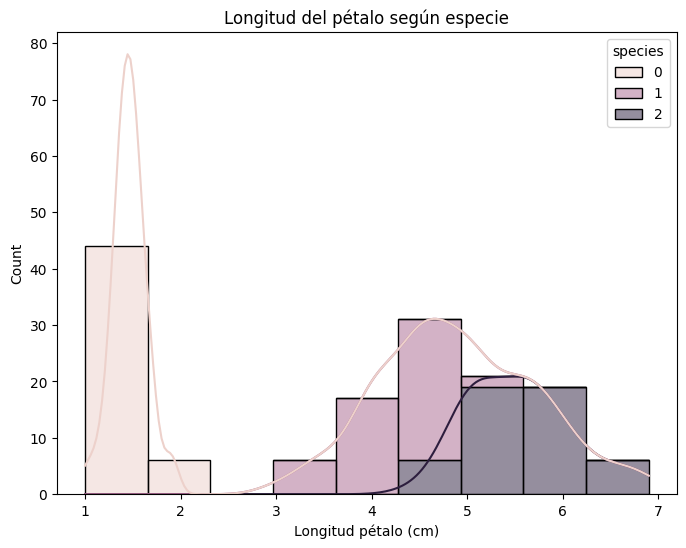

In [59]:
plt.figure(figsize=(8, 6))
sns.histplot(data=iris_df, x='petal length (cm)', hue='species', multiple='stack', kde=True)
plt.title('Longitud del pétalo según especie')
plt.xlabel('Longitud pétalo (cm)')
plt.show()

Podemos ver sin embargo que hay dos especies que están **bastante superpuestas**, asi que esperaríamos que el modelo no logre separarlas bastante bien.

Tomando esto en cuenta procedo a generar un modelo de mezcla basado en 3 componentes tal y como propone el enunciado:

In [37]:
petal_length = iris_df['petal length (cm)'].values
k = 3

with pm.Model() as iris_mixture:
    w = pm.Dirichlet('w', a=np.ones(k))
    μ = pm.Normal('μ',
                  mu=np.quantile(petal_length, np.linspace(0.1, 0.9, k)),
                  sigma=petal_length.var() / k,
                  shape=k,
                  transform=pm.distributions.transforms.ordered,
                  )
    σ = pm.HalfNormal('σ', sigma=5)
    x = pm.NormalMixture('x', w=w, mu=μ, sigma=σ, observed=petal_length)
    idata_iris = pm.sample(random_seed=123,
                      progress_bar=False
                      )

Output()

Una forma de verificar su desempeño es analizar la distribución predictiva *a posteriori*, por lo tanto procedo a tomar muestras de la misma:

In [38]:
with iris_mixture:
  idata_iris.extend(pm.sample_posterior_predictive(idata_iris, progressbar=False))

Genero el gráfico:

[]

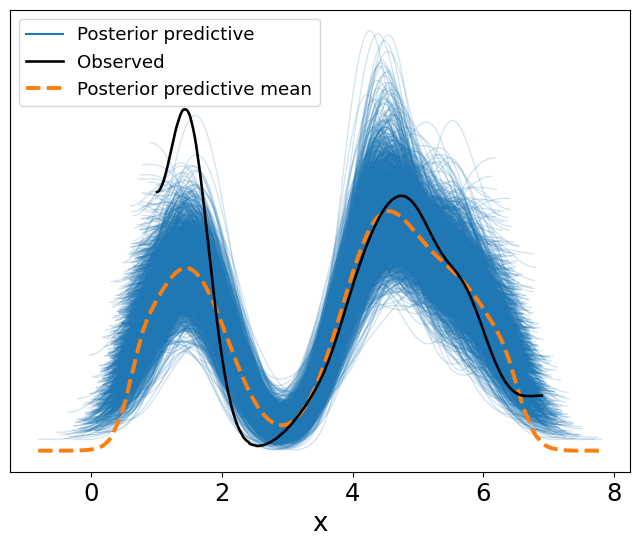

In [55]:
az.plot_ppc(idata_iris, figsize=(8, 6))
plt.plot()

Podemos ver que el modelo captó las dos distribuciones dominantes presentes entre los datos, **aunque sabemos que hay 3 especies**. Esto está más relacionado con la capacidad de la característica elegida para separar especies que con el modelo en sí mismo, sin embargo nos podemos quedar con el hecho de que hizo un buen trabajo.